<a href="https://colab.research.google.com/github/ablamitovroman/data-analysis-practice/blob/main/Jan_Feb_Regionen_Analyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Название проекта: **`01_Jan_Feb_Regionen_Analyse`**

---

### Практическая задача: Имитация реального процесса (CSV $\rightarrow$ Фильтрация $\rightarrow$ Агрегация $\rightarrow$ График)

#### Шаг 1. Создание и сохранение CSV-файла

Создай исходный `DataFrame` с данными и сохрани его в файл `"umsatz_data.csv"` через `.to_csv()`:

In [3]:
import pandas as pd

data = {
    "Bestell_ID": [1, 2, 3, 4, 5, 6],
    "Datum": ["2026-01-10", "2026-01-20", "2026-02-05", "2026-02-18", "2026-03-02", "2026-03-15"],
    "Region": ["Nord", "Süd", "Nord", "Süd", "Nord", "Süd"],
    "Betrag": [200.0, 150.0, 300.0, 400.0, 100.0, 250.0]
}
df=pd.DataFrame(data)
#print(df)
df.to_csv("umsatz_data.csv", index=False)
# ТВОЙ КОД:
# 1. Создай DataFrame (df_all)
# 2. Сохрани в "umsatz_data.csv" (index=False)

#### Шаг 2. Основной скрипт обработки

Напиши скрипт в блоке `try-except`, который считывает созданный файл и выполняет обработку:

1. Считай данные из `"umsatz_data.csv"` с помощью `pd.read_csv()`.
2. Переведи столбец `"Datum"` в `datetime`.
3. Отфильтруй данные: оставь только заказы **с `2026-01-01` по `2026-02-28**`.
*(Подсказка по синтаксису: `(df["Datum"] >= "2026-01-01") & (df["Datum"] <= "2026-02-28")`)*
4. Сгруппируй отфильтрованный `DataFrame` по столбцу `"Region"` и посчитай общую сумму продаж (`"Betrag"`).
5. Построй столбчатую диаграмму (`plt.bar`) суммы продаж по регионам за этот период и сохрани график в файл `"jan_feb_regionen.png"`.

Жду твой код!

#Datei auslesen

   Bestell_ID       Datum Region  Betrag
0           1  2026-01-10   Nord   200.0
1           2  2026-01-20    Süd   150.0
2           3  2026-02-05   Nord   300.0
3           4  2026-02-18    Süd   400.0
4           5  2026-03-02   Nord   100.0
5           6  2026-03-15    Süd   250.0
   Bestell_ID      Datum Region  Betrag
0           1 2026-01-10   Nord   200.0
1           2 2026-01-20    Süd   150.0
2           3 2026-02-05   Nord   300.0
3           4 2026-02-18    Süd   400.0
  Region  Umsatz
0   Nord   500.0
1    Süd   550.0


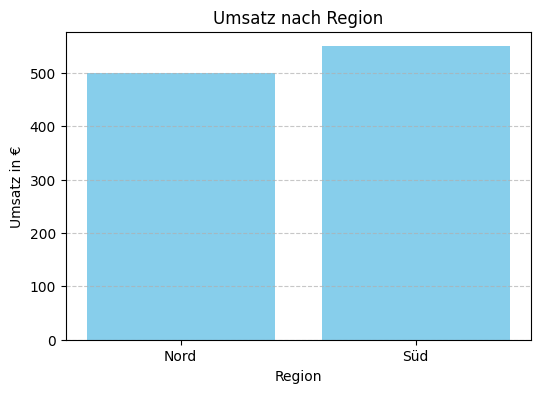

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

try:
  df = pd.read_csv("umsatz_data.csv")
  print(df)
  df["Datum"]=pd.to_datetime(df['Datum'])
  df_bis_feb = df[df['Datum'].dt.month<=2]
  print(df_bis_feb)
  df_region = (
      df_bis_feb
      .groupby("Region", as_index=False)
      .agg(
          Umsatz = ("Betrag", "sum")
      )
  )
  print (df_region)

  plt.figure(figsize=(6, 4))
  plt.bar(df_region["Region"], df_region["Umsatz"], color="skyblue")

  plt.title("Umsatz nach Region")
  plt.xlabel("Region")
  plt.ylabel("Umsatz in €")
  plt.grid(axis="y", linestyle="--", alpha=0.7)

  plt.savefig("jan_feb_regionen.png", dpi=300, bbox_inches="tight")
  plt.show()

  df_region.to_csv("Sortierte Tabelle.csv", index=False)

except FileNotFoundError as err:
  print(f"Bitte vorherigen Block ausführen, weil das Datei umsatz_data.csv nicht gefunden wurde\n{err}")
